In [12]:
# Preliminary features & parameters
import src.simulations.backtest_portfolio_v2 as bp
from src import indicators

features = {
        'sma_trend_regime': {
            'func': indicators.calculate_sma_crossover,
            'params': {'fast_window': 10, 'slow_window': 30, 'binary': True},
        },
        'sma_position_fast': {
            'func': indicators.calculate_sma_position,
            'params': {'window': 10},
        },
        'sma_position_slow': {
            'func': indicators.calculate_sma_position,
            'params': {'window': 30}
        },
        'rsi': {
            'func': indicators.calculate_rsi,
            'params': {'window': 14},
        },
        'bollinger_position': {
            'func': indicators.calculate_bollinger_position,
            'params': {'window': 20, 'num_std': 2},
        },
        'price_roc_fast': {
            'func': indicators.calculate_roc,
            'params': {'window': 1}
        },
        'price_roc_slow': {
            'func': indicators.calculate_roc,
            'params': {'window': 5}
        },
    }

# Use QQQ
ticker_pool_tech = [
        "NVDA", "MSFT", "AVGO", "NOW",
        "ORCL", "AAPL", "TEAM", "INTC",
        "SNOW", "WIX",  "AMD",  "CSCO",
        "SHOP", "AMZN", "CRM",
    ]

# Use SPY
ticker_pool_general = [
    "NVDA", "MSFT", "AAPL", "AMZN", "GOOGL",
    "UNH", "LLY", "JNJ",
    "XOM", "CVX",
    "JPM", "BRK-B",
    "WMT", "PG",
    "GLD"
]

ticker_pool_general = [
    "NVDA", "MSFT", "AAPL", "AMZN", "GOOGL",
    "UNH", "LLY", "JNJ",
    "XOM", "CVX",
    "JPM", "BRK-B",
    "WMT", "PG",
    "GLD", "SPY"
]

ticker_pool_etfs = [
    "XLK", # Technology
    "XLV", # Healthcare
    "XLE", # Energy
    "XLF", # Financials
    "XLP", # Consumer Staples
    "XLY", # Consumer Discretionary
    "XLI", # Industrials
    "XLB", # Materials
    "XLU", # Utilities
    "XLRE",# Real Estate
    "XLC", # Communication Services
    "GLD", # Gold
    "TLT", # Long-term Bonds
    "IYZ", # Telecom
    "VNQ", # REITs
]

ticker_pool_balanced = [
    "NVDA", "LLY", "JPM", "GLD", "WMT",
    "MSFT", "AMZN", "PG", "UNH", "XOM", 
    "INTC", "PFE", "DIS", "BABA", "T"
]

ticker_pool = ticker_pool_balanced
 
benchmark = "SPY"

In [13]:
# Functionize model testing & plotting
import src.stock_screener as sc
import matplotlib.pyplot as plt
import seaborn as sns

def run_with_model(input_model, features_dict):
    engine = bp.PortfolioBacktestEngine(
        model=input_model,
        feature_configs=features_dict,
        confidence_threshold=0.60,
        bear_confidence_threshold=0.75,
        stop_loss=0.10,
        min_hold_days=7,
        adx_threshold=20,
        training_years=5,
        testing_years=5,
        offset_years=0
    )

    total_years = engine.training_years + engine.testing_years + engine.offset_years
    print(f"Downloading {total_years}y of data for {len(ticker_pool)} tickers + {benchmark}...")
    master_df = sc.fetch_screener_data(
        ticker_pool + [benchmark], period=f"{total_years}y", interval="1d"
    )
    print("Download Complete.")

    benchmark_prices = master_df['Close'][benchmark]
    benchmark_prices.name = benchmark

    engine.run_simulation(
        ticker_pool=ticker_pool,
        pre_downloaded_df=master_df,
        benchmark_prices=benchmark_prices,
    )

    print("\nTrade Log:")
    print(engine.last_trade_log.to_string(index=False))
    return engine, benchmark_prices

def plot_results(engine, benchmark_prices):
    sns.set_theme(style='darkgrid')
    bench = benchmark_prices.loc[engine.last_equity_curve.index]
    bench = bench / bench.iloc[0] * 10_000

    plt.figure(figsize=(12, 5))
    plt.plot(engine.last_equity_curve, label='Strategy', color='#2ecc71', linewidth=2)
    plt.plot(bench, label='Benchmark', color='#3498db', linewidth=2, linestyle='--')
    plt.title(f"Strategy {engine.last_strategy_return:+.2f}% | {benchmark} {engine.last_benchmark_return:+.2f}% | Alpha {engine.last_alpha:+.2f}%", fontsize=13)
    plt.ylabel('Portfolio Value')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching historical data for companies: ['NVDA', 'LLY', 'JPM', 'GLD', 'WMT', 'MSFT', 'AMZN', 'PG', 'UNH', 'XOM', 'INTC', 'PFE', 'DIS', 'BABA', 'T', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2016-06-27 to 2021-06-25
  Test window  : 2021-06-28 to 2026-06-26
  Strategy Return   : +250.14%
  Benchmark (SPY) : +77.42%
  Alpha             : +172.73%
  Win Rate          : 54.90%
  Total Trades      : 153

Trade Log:
     type ticker       price       date     return
      BUY    GLD  161.720001 2021-08-09        NaN
     SELL    GLD  167.100006 2021-08-18   3.326741
      BUY   NVDA   18.974371 2021-08-18        NaN
     SELL   NVDA   22.557974 2021-08-27  18.886544
      BUY      T   15.357243 2021-08-27        NaN
     SELL      T   15.623289 2021-09-08   1.732385
      BUY    LLY  243.880859 2021-09-08        NaN
     SELL    LLY  221.678558 2021-09-20  -9.103749
      BUY   NVDA   21.043934 2021-09-20        NaN
     SELL   NVDA   20.449884 2021-09-29  -2.822901
      BUY   MSFT  273.075684 2021-09-29        NaN
     SELL   MSFT  283.508301 2021-10-08   3.820412
      BUY    PFE   33.151249 2021-10-08        

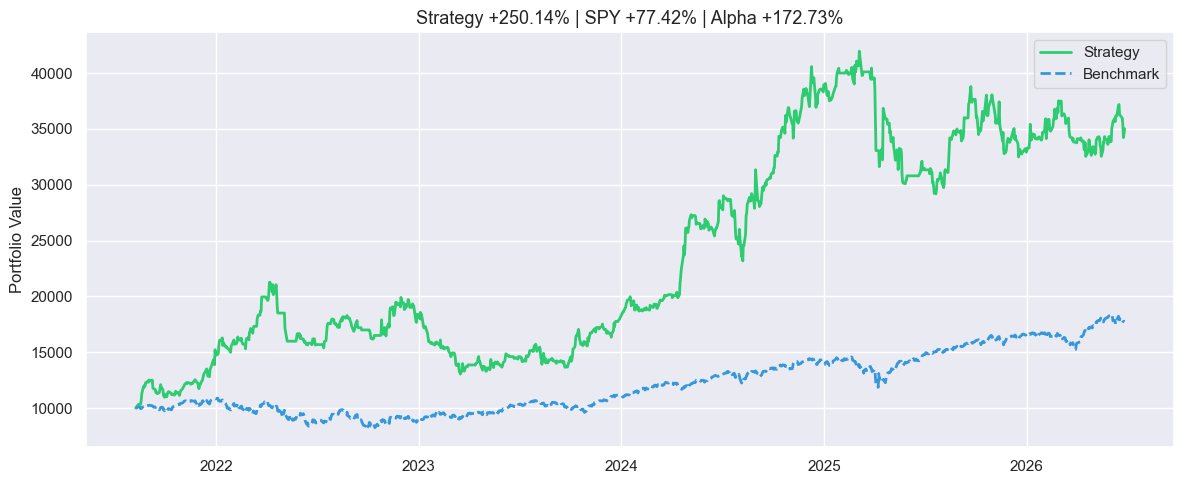

In [14]:
from sklearn import ensemble
rf_classifier = ensemble.RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        min_samples_split=10,
        max_features='sqrt',
        max_depth=10
    )
engine, benchmark_prices = run_with_model(input_model=rf_classifier, features_dict=features)
plot_results(engine, benchmark_prices)

Fetching historical data for companies: ['NVDA', 'LLY', 'JPM', 'GLD', 'WMT', 'MSFT', 'AMZN', 'PG', 'UNH', 'XOM', 'INTC', 'PFE', 'DIS', 'BABA', 'T', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2016-06-27 to 2021-06-25
  Test window  : 2021-06-28 to 2026-06-26
  Strategy Return   : +168.74%
  Benchmark (SPY) : +77.37%
  Alpha             : +91.37%
  Win Rate          : 51.66%
  Total Trades      : 151

Trade Log:
     type ticker       price       date     return
      BUY    GLD  161.720001 2021-08-09        NaN
     SELL    GLD  167.100006 2021-08-18   3.326741
      BUY   AMZN  160.061005 2021-08-18        NaN
     SELL   AMZN  167.481506 2021-08-27   4.636046
      BUY   BABA  150.069626 2021-08-27        NaN
     SELL   BABA  160.647049 2021-09-08   7.048344
      BUY    LLY  243.880890 2021-09-08        NaN
     SELL    LLY  220.271774 2021-09-21  -9.680593
      BUY   BABA  141.327240 2021-09-21        NaN
     SELL   BABA  139.322815 2021-09-30  -1.418286
      BUY    UNH  359.176666 2021-09-30        NaN
     SELL    UNH  372.275635 2021-10-11   3.646943
      BUY    PFE   32.846672 2021-10-11        N

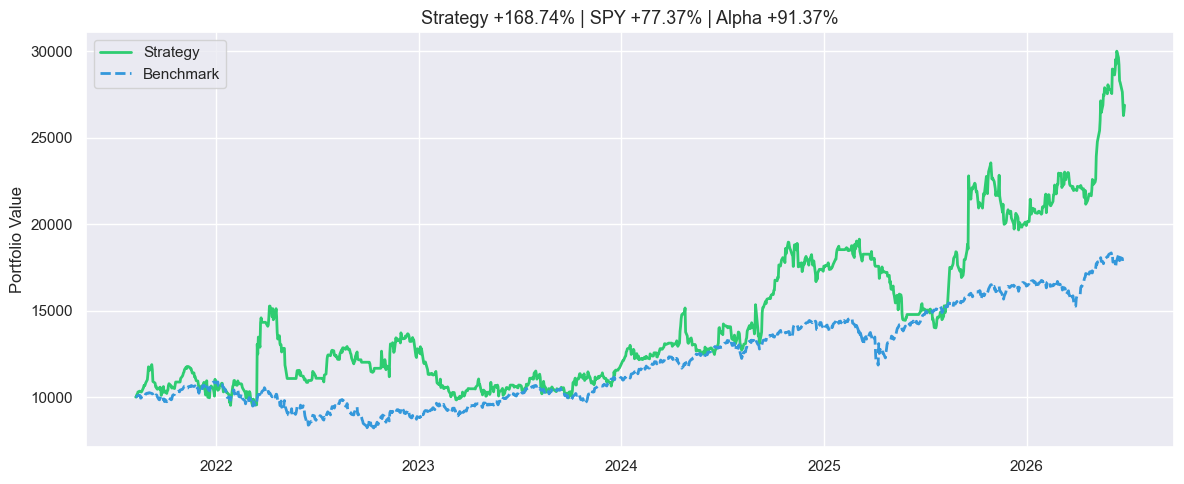

In [15]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05)

engine, benchmark_prices = run_with_model(input_model=xgb_model, features_dict=features)
plot_results(engine, benchmark_prices)

Fetching historical data for companies: ['NVDA', 'LLY', 'JPM', 'GLD', 'WMT', 'MSFT', 'AMZN', 'PG', 'UNH', 'XOM', 'INTC', 'PFE', 'DIS', 'BABA', 'T', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2016-06-27 to 2021-06-25
  Test window  : 2021-06-28 to 2026-06-26
  Strategy Return   : +65.01%
  Benchmark (SPY) : +77.39%
  Alpha             : -12.38%
  Win Rate          : 52.00%
  Total Trades      : 150

Trade Log:
     type ticker       price       date     return
      BUY    GLD  161.720001 2021-08-09        NaN
     SELL    GLD  167.100006 2021-08-18   3.326741
      BUY   BABA  162.190399 2021-08-18        NaN
     SELL   BABA  157.146362 2021-08-31  -3.109948
      BUY    PFE   35.978275 2021-08-31        NaN
     SELL    PFE   35.603416 2021-09-10  -1.041903
      BUY    LLY  229.200531 2021-09-10        NaN
     SELL    LLY  220.271820 2021-09-21  -3.895589
      BUY   BABA  141.327240 2021-09-21        NaN
     SELL   BABA  139.322815 2021-09-30  -1.418286
      BUY    UNH  359.176666 2021-09-30        NaN
     SELL    UNH  372.275635 2021-10-11   3.646943
      BUY    PFE   32.846676 2021-10-11        Na

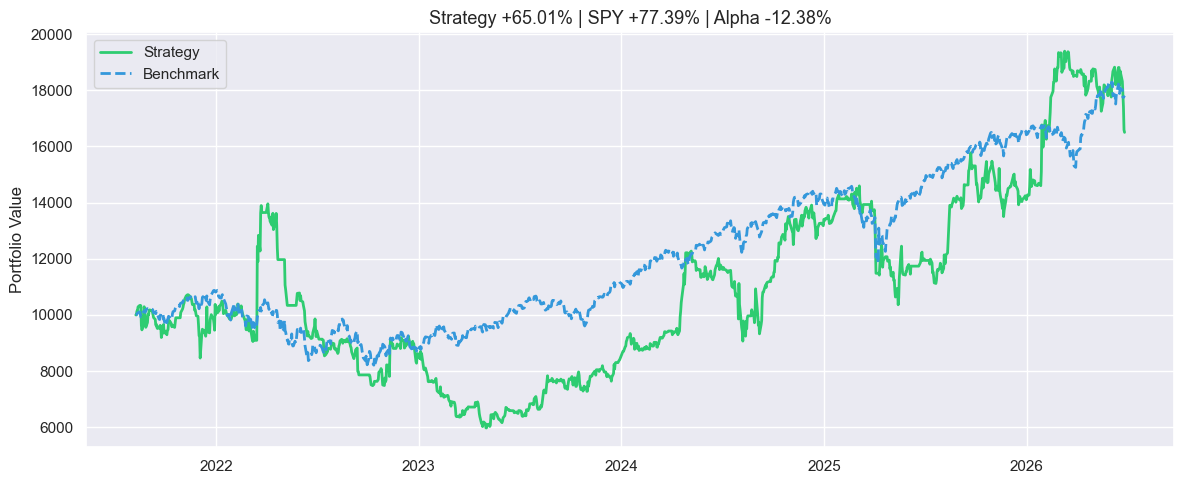

In [16]:
from sklearn.linear_model import LogisticRegression

# There was some noise based on dividing by 0, etc. that we filter out
import warnings
warnings.filterwarnings('ignore')

logreg_model = LogisticRegression(C=0.1)

engine, benchmark_prices = run_with_model(input_model=logreg_model, features_dict=features)
plot_results(engine, benchmark_prices)